# Генеративные нейросети
## Задание 4

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.



**Баллы за задание:**
* Задача 1 — 30 баллов.


-----------

In [1]:
# Bot check

# HW_ID: ds_gen4
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована
...

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(palette='Set2', font_scale=1.3)

import torch

Вы 

    так ждали..., 

        так просили,...

            и, наконец,...
        
                это случилось! 😱🙊😳
             
Задача про генерацию **красивых картинок**!!! 😍🥰🥳😎😻

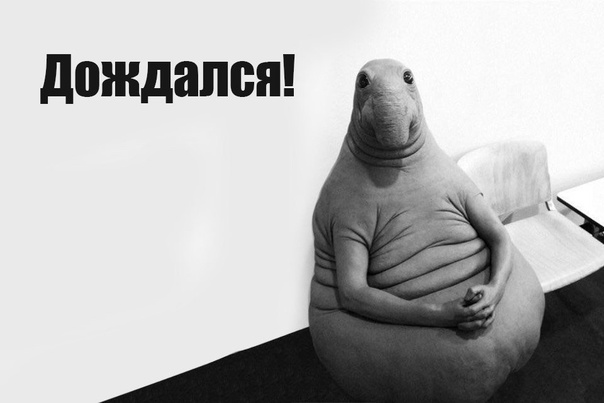

---
### Задача 1
Творческое задание "Почувствуй себя художником".
* Сгенерируйте несколько изображений, соответствующих тематике DS-потока.  
* Вы можете использовать различные модели: разные версии Stable Diffusion, SDXL, SDXL-Turbo, Kandisnky, Fooocus, ControlNet, диффузионные модели миксинга, вариаций изображений и т.п. (поиск в интернете вам в помощь 🙏)
* Используйте хотя бы 3 разных метода генерации.
* **Код запуска для итоговых генераций должен быть представлен в ноутбуке.**
* Фиксируйте рэндом стейт для воспроизводимости результатов.
* **Выберите от одного до трех наиболее понравившихся вам изображений. Их необходимо добавить в [форму](https://forms.gle/ZyFBvvhkLTUvDzPD8).**
* Оценивание будет происходить в том числе на основе ранжирования сгенерированных изображений вашими однокурсниками.

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "20"
os.environ["MKL_NUM_THREADS"] = "20"
os.environ["NUMEXPR_NUM_THREADS"] = "20"
os.environ["OPENBLAS_NUM_THREADS"] = "20"

import torch
import numpy as np
import random
import logging

from diffusers import AutoPipelineForText2Image
from huggingface_hub import hf_hub_download
from diffusers import StableDiffusionPipeline, ControlNetModel, UniPCMultistepScheduler
from diffusers import StableDiffusion3Pipeline
from diffusers import DiffusionPipeline
from diffusers import FluxPipeline
import torch
from PIL import Image


torch.set_num_threads(20)
torch.set_num_interop_threads(20)

device = "cuda"

In [4]:
def set_seed(seed: int = 42):
    """
    Фиксирует сиды для воспроизводимости результатов.

    Args:
        seed (int): Число для инициализации генераторов случайных чисел.
    """
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(42)

In [5]:
logging.basicConfig(level=logging.INFO)

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    dtype=torch.float16,
).to("cuda")

image = pipe(
    "photo of a 2000s Russian computer club, CRT monitors, Counter-Strike 1.6 LAN game, realistic lighting, nostalgic atmosphere",
    num_inference_steps=8,
).images[0]

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/8 [00:00<?, ?it/s]

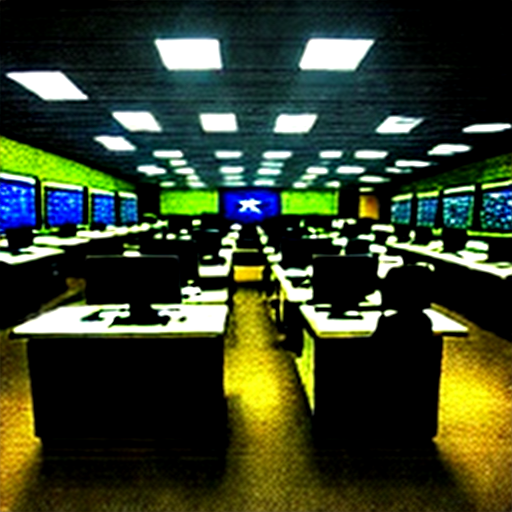

In [6]:
display(image)

In [7]:
del pipe  # удаляем объект модели
torch.cuda.empty_cache()

In [8]:
pipe = DiffusionPipeline.from_pretrained(
    "cagliostrolab/animagine-xl-3.1", 
    torch_dtype=torch.float16, 
    use_safetensors=True, 
)
pipe.to('cuda')

model_index.json:   0%|          | 0.00/680 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "cagliostrolab/animagine-xl-3.1",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerAncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/28 [00:00<?, ?it/s]

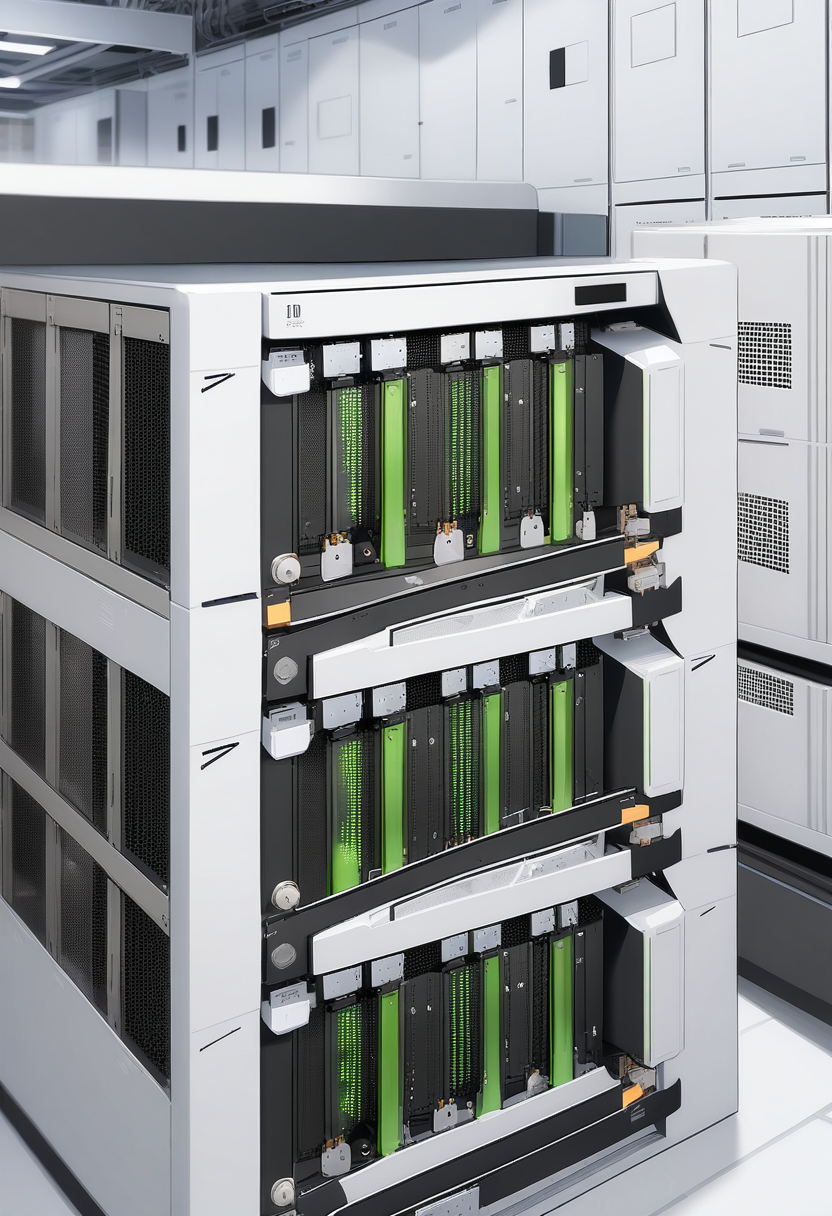

In [9]:
prompt = "data center, stocks with gpu"
negative_prompt = "lowres, (bad), text, error, fewer, extra, missing, worst quality, jpeg artifacts, low quality, watermark, unfinished, displeasing, oldest, early, chromatic aberration, signature, extra digits, artistic error, username, scan, [abstract]"

image = pipe(
    prompt, 
    negative_prompt=negative_prompt,
    width=832,
    height=1216, 
    guidance_scale=7,
    num_inference_steps=28
).images[0]
display(image)


In [10]:
del pipe          # удаляем объект модели
torch.cuda.empty_cache()

In [11]:
pipe = DiffusionPipeline.from_pretrained(
    "SG161222/RealVisXL_V4.0",
    torch_dtype=torch.bfloat16,
).to("cuda")


model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/602 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

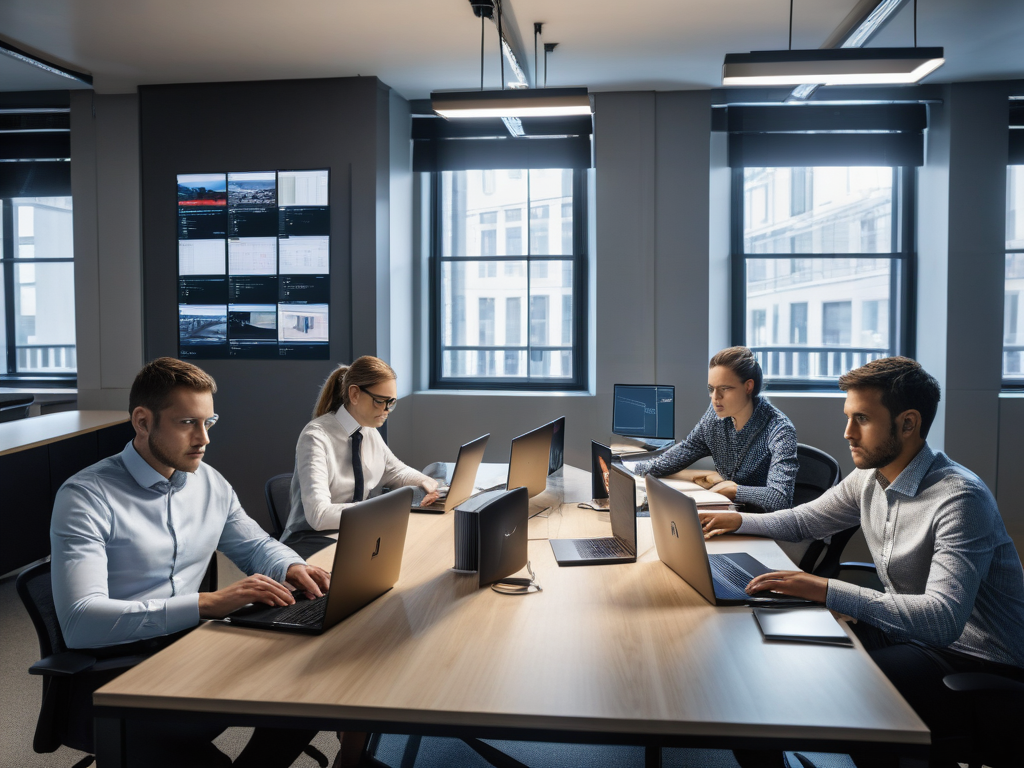

In [12]:
prompt = (
    "a small modern office room with six people sitting around one large table, "
    "each using laptops, collaborating closely on data annotation tasks, "
    "their screens showing image labeling software with bounding boxes and dataset images, "
    "focused teamwork, realistic lighting from windows, "
    "natural light, cables and notebooks on the table, "
    "professional data labeling workspace, high detail, realistic photo"
)

negative_prompt = (
    "lowres, bad anatomy, text, watermark, extra hands, missing fingers, blurry, low quality, "
    "worst quality, jpeg artifacts, unfinished, cartoon, painting, drawing, unrealistic"
)

image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    width=1024,
    height=768,
    guidance_scale=7,
    num_inference_steps=40,
).images[0]
display(image)


In [13]:
del pipe          # удаляем объект модели
torch.cuda.empty_cache()

Возьмем модель, умеюющую работать в разных стилях.

In [14]:
from diffusers import (
    StableDiffusionXLPipeline, 
    KDPM2AncestralDiscreteScheduler,
    AutoencoderKL
)

In [15]:
vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix", 
    torch_dtype=torch.float16
)

# Configure the pipeline
pipe = StableDiffusionXLPipeline.from_pretrained(
    "dataautogpt3/ProteusV0.5", 
    vae=vae,
    torch_dtype=torch.float16
)
pipe.scheduler = KDPM2AncestralDiscreteScheduler.from_config(pipe.scheduler.config)
pipe.to('cuda')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "dataautogpt3/ProteusV0.5",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "KDPM2AncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/40 [00:00<?, ?it/s]

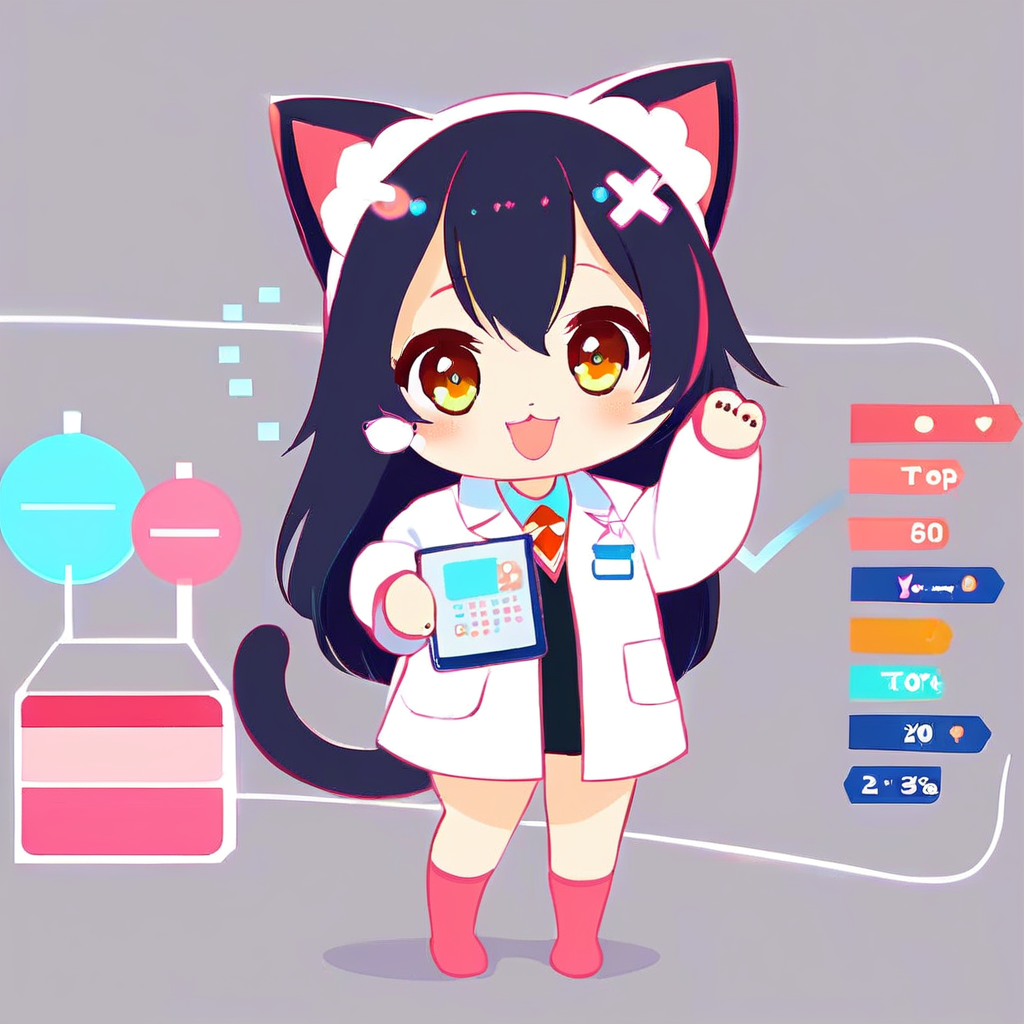

In [16]:
prompt = (
    "Scientific graph: x-axis 'compute time', y-axis 'calculated proteins', "
    "smooth exponential curve, white background, clean axes with ticks, "
    "top-right: cute anime cat girl with cat ears, big eyes, futuristic lab coat, "
    "holding glowing data pad, smiling at graph, anime + infographic style"
)

negative_prompt = (
    "blurry, low-res, distorted graph, messy axes, unreadable text, "
    "extra lines, no labels, deformed hands, bad anatomy, extra limbs, "
    "realistic, photo, 3D, western cartoon, grayscale, cluttered, watermark"
)

image = pipe(
    prompt, 
    negative_prompt=negative_prompt, 
    width=1024,
    height=1024,
    guidance_scale=7,
    num_inference_steps=40
).images[0]

display(image)

In [ ]:
del pipe          # удаляем объект модели
torch.cuda.empty_cache()


---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока